In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from groq import Groq

client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)

models = client.models.list()

In [ ]:
chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain the importance of fast language models",
        }
    ],
    model="llama-3.3-70b-versatile",
)

print(chat_completion.choices[0].message.content)

Fast language models are essential for various reasons and have numerous applications in natural language processing (NLP). Here are some of the key importance of fast language models:

1. **Improved User Experience**: Fast language models enable applications to respond quickly to user input, providing a seamless and efficient user experience. This is particularly crucial for applications that require real-time interaction, such as chatbots, virtual assistants, and language translation software.
2. **Increased Productivity**: Fast language models can process and analyze large amounts of text data rapidly, enabling businesses and organizations to automate tasks, such as text classification, sentiment analysis, and information extraction. This automation saves time and increases productivity, allowing humans to focus on higher-level tasks.
3. **Real-Time Decision Making**: Fast language models can provide instant insights and analysis, enabling decision-makers to respond quickly to chang

In [8]:
models

ModelListResponse(data=[Model(id='groq/compound-mini', created=1756949707, object='model', owned_by='Groq', active=True, context_window=131072, public_apps=None, max_completion_tokens=8192), Model(id='qwen/qwen3-32b', created=1748396646, object='model', owned_by='Alibaba Cloud', active=True, context_window=131072, public_apps=None, max_completion_tokens=40960), Model(id='whisper-large-v3-turbo', created=1728413088, object='model', owned_by='OpenAI', active=True, context_window=448, public_apps=None, max_completion_tokens=448), Model(id='openai/gpt-oss-safeguard-20b', created=1761708789, object='model', owned_by='OpenAI', active=True, context_window=131072, public_apps=None, max_completion_tokens=65536), Model(id='openai/gpt-oss-20b', created=1754407957, object='model', owned_by='OpenAI', active=True, context_window=131072, public_apps=None, max_completion_tokens=65536), Model(id='meta-llama/llama-prompt-guard-2-86m', created=1748632165, object='model', owned_by='Meta', active=True, con

In [ ]:
import json
import uuid
from typing import Dict, Any, List, Optional
from pathlib import Path
from qdrant_client import QdrantClient, models
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

class HFDocIndexer:
    def __init__(
        self,
        embedding_model: str = "intfloat/multilingual-e5-large",
        qdrant_url: str = "http://localhost:6333",
        collection_name: str = "hf_docs_rag",
        chunk_size: int = 512,
        chunk_overlap: int = 64,
        batch_size: int = 100
    ):
        self.embedder = SentenceTransformer(embedding_model)
        self.qdrant = QdrantClient(url=qdrant_url)
        self.collection_name = collection_name
        self.batch_size = batch_size
        
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ". ", " ", ""]
        )
        
        self._ensure_collection()

    def _ensure_collection(self):
        """Создает коллекцию, если её нет."""
        collections = [c.name for c in self.qdrant.get_collections().collections]
        if self.collection_name not in collections:
            self.qdrant.create_collection(
                collection_name=self.collection_name,
                vectors_config=VectorParams(
                    size=self.embedder.get_sentence_embedding_dimension(),
                    distance=Distance.COSINE
                )
            )
            print(f"Коллекция '{self.collection_name}' создана.")
        else:
            print(f"Коллекция '{self.collection_name}' уже существует.")

    def _load_jsonl(self, jsonl_path: str) -> List[Dict[str, Any]]:
        """Загружает JSONL файл."""
        documents = []
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:  # пропускаем пустые строки
                    continue
                try:
                    doc = json.loads(line)
                    documents.append(doc)
                except json.JSONDecodeError as e:
                    print(f"Ошибка в строке {line_num}: {e}")
                    continue
        return documents

    def _create_points_from_document(
        self, 
        doc: Dict[str, Any], 
        doc_id: int
    ) -> List[PointStruct]:
        """Создает точки Qdrant из одного документа."""
        # Извлекаем текст - проверяем разные возможные ключи
        text = doc.get("text") or doc.get("content") or doc.get("body")
        if not text:
            return []
        
        # Создаем чанки
        chunks = self.splitter.split_text(text)
        
        # Генерируем эмбеддинги
        embeddings = self.embedder.encode(
            chunks, 
            normalize_embeddings=True, 
            show_progress_bar=False
        )
        
        # Формируем metadata из всех полей документа кроме 'text'
        base_metadata = {k: v for k, v in doc.items() if k != "text"}
        base_metadata["doc_id"] = doc_id  # ID оригинального документа
        
        points = []
        for chunk_idx, (chunk, vec) in enumerate(zip(chunks, embeddings)):
            payload = {
                "text": chunk,              # сам чанк (для реранкера)
                "chunk_idx": chunk_idx,     # номер чанка в документе
                "total_chunks": len(chunks),
                **base_metadata             # все остальные поля из JSON
            }
            
            points.append(PointStruct(
                id=str(uuid.uuid4()),
                vector=vec.tolist(),
                payload=payload
            ))
        
        return points

    def index_jsonl(
        self, 
        jsonl_path: str,
        max_docs: Optional[int] = None
    ):
        """
        Индексирует JSONL файл.
        
        Args:
            jsonl_path: путь к JSONL файлу
            max_docs: максимальное количество документов для обработки (None = все)
        """
        print(f"Загрузка JSONL из {jsonl_path}...")
        documents = self._load_jsonl(jsonl_path)
        
        if max_docs:
            documents = documents[:max_docs]
            print(f"Обработка первых {len(documents)} документов...")
        else:
            print(f"Найдено {len(documents)} документов.")
        
        all_points = []
        total_chunks = 0
        
        # Обрабатываем каждый документ
        for doc_idx, doc in enumerate(tqdm(documents, desc="Чанкинг")):
            points = self._create_points_from_document(doc, doc_id=doc_idx)
            if points:
                all_points.extend(points)
                total_chunks += len(points)
        
        print(f"\nВсего создано чанков: {total_chunks}")
        print(f"Загрузка в Qdrant (batch_size={self.batch_size})...")
        
        # Пакетная загрузка в Qdrant
        for i in tqdm(range(0, len(all_points), self.batch_size), desc="Upload"):
            batch = all_points[i:i + self.batch_size]
            self.qdrant.upsert(
                collection_name=self.collection_name,
                points=batch
            )
        
        print(f"Успешно проиндексировано {total_chunks} чанков из {len(documents)} документов!")
        return len(documents), total_chunks

    def search(
        self, 
        query: str, 
        top_k: int = 10,
        filter_payload: Optional[Dict] = None
    ):
        vec = self.embedder.encode([query], normalize_embeddings=True)[0].tolist()
        
        query_filter = None
        if filter_payload:
            conditions = [
                models.FieldCondition(
                    key=key,
                    match=models.MatchValue(value=value)
                )
                for key, value in filter_payload.items()
            ]
            query_filter = models.Filter(must=conditions)
        
        response = self.qdrant.query_points(
            collection_name=self.collection_name,
            query=vec,           
            limit=top_k,
            with_payload=True,
            query_filter=query_filter
        )
        
        return [
            {
                "text": point.payload.get("text"),
                "score": point.score,
                "chunk_idx": point.payload.get("chunk_idx"),
                "doc_id": point.payload.get("doc_id"),
                "metadata": {k: v for k, v in point.payload.items() 
                            if k not in ["text", "chunk_idx", "doc_id", "total_chunks"]}
            }
            for point in response.points
        ]

/Users/zapashniysergey/Downloads/vs code docs /VKR_HSE/rag_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
indexer = HFDocIndexer(
    embedding_model="intfloat/multilingual-e5-large",
    collection_name="hf_corpus",
    chunk_size=400,
    chunk_overlap=50
)

# indexer.index_jsonl("rag_corpus_cleaned_v2/corpus.jsonl")


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 12219.54it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Коллекция 'hf_corpus' уже существует.


In [ ]:
# Поиск
results = indexer.search(
    query="how to use pipeline for text classification",
    top_k=5
)

print("\n Результаты поиска:")
for i, r in enumerate(results, 1):
    print(f"\n{i}. Score: {r['score']:.4f}")
    print(f"   Text: {r['text'][:150]}...")
    print(f"   Doc ID: {r['doc_id']}, Chunk: {r['chunk_idx']}")
    if r['metadata']:
        print(f"   Metadata: {r['metadata']}")


🔍 Результаты поиска:

1. Score: 0.8896
   Text: . For example, a custom pipeline for sentence pair classification might look like the following code below. Save the code in a file named , and import...
   Doc ID: 69, Chunk: 5
   Metadata: {'source': 'add_new_pipeline.md', 'library': 'transformers'}

2. Score: 0.8735
   Text: . For example, add a parameter in to return the top 5 most likely classes. Then in , check if the user passed in and add it to . Now the pipeline can ...
   Doc ID: 69, Chunk: 2
   Metadata: {'source': 'add_new_pipeline.md', 'library': 'transformers'}

3. Score: 0.8612
   Text: TextGenerationPipeline - __call__ - all TokenClassificationPipeline [[autodoc]] TokenClassificationPipeline - __call__ - all ZeroShotClassificationPip...
   Doc ID: 325, Chunk: 1
   Metadata: {'source': 'main_classes/pipelines.md', 'library': 'transformers'}

4. Score: 0.8591
   Text: the model. Pipeline The fastest way to get started is to use the [] API. Specify the task and the model you

In [ ]:
import json
import pandas as pd
from typing import List, Dict
from datasets import Dataset

# Импорты RAGAS
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

# Импорты для Groq (через LangChain)
from langchain_groq import ChatGroq

class RAGASEvaluator:
    def __init__(self, indexer, groq_api_key: str, model: str = "llama-3.3-70b-versatile"):
        self.indexer = indexer
        
        # 1. Создаем LLM-объект для RAGAS (судья)
        # RAGAS использует этот объект для оценки метрик
        self.judge_llm = ChatGroq(
            model_name=model,
            groq_api_key=groq_api_key,
            temperature=0.0
        )
        
        # 2. Создаем LLM-объект для генерации ответов (мой RAG)
        self.generator_llm = ChatGroq(
            model_name=model,
            groq_api_key=groq_api_key,
            temperature=0.0
        )

    def _generate_rag_response(self, query: str, top_k: int = 5) -> tuple[str, List[str]]:
        """Генерирует ответ через ваш RAG-пайплайн."""
        # Поиск
        results = self.indexer.search(query, top_k=top_k)
        contexts = [r["text"] for r in results]
        
        context_text = "\n\n".join([f"[{i+1}] {c}" for i, c in enumerate(contexts)])
        prompt = f"""Ты — помощник по документации Hugging Face.
Используй только предоставленный контекст для ответа.

Контекст:
{context_text}

Вопрос: {query}

Ответ:"""
        
        # Генерация
        response = self.generator_llm.invoke(prompt)
        return response.content, contexts

    def prepare_dataset(self, json_path: str, max_samples: int = None) -> Dataset:
        """Конвертирует ваш JSON в формат RAGAS Dataset."""
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        if max_samples:
            data = data[:max_samples]
            
        rows = []
        print("Генерация ответов RAG-системой...")
        for i, item in enumerate(data):
            query = item["query"]
            # Генерируем ответ системой
            answer, contexts = self._generate_rag_response(query)
            
            # Извлекаем эталонный ответ (если есть)
            ground_truth = item.get("expected_answer", "")
            
            rows.append({
                "user_input": query,
                "retrieved_contexts": contexts,
                "response": answer,
                "reference": ground_truth  # Опционально, для метрик типа context_recall
            })
            print(f"  [{i+1}/{len(data)}] Обработан: {query[:50]}...")
            
        return Dataset.from_list(rows)

    def run_evaluation(self, dataset: Dataset) -> Dict:
        """Запускает оценку."""
        print("\n Запуск оценки метрик (LLM-as-a-Judge через Groq)...")
        
        # Настраиваем метрики с нашим Groq-судьей
        metrics = [
            faithfulness,
            answer_relevancy,
            context_precision,
            context_recall,
        ]
        
        # Передаем LLM в метрики (в новых версиях RAGAS это можно делать глобально или в evaluate)
        # RAGAS автоматически подхватит llm из контекста или можно задать явно:
        # faithfulness.llm = self.judge_llm 
        
        results = evaluate(
            dataset=dataset,
            metrics=metrics,
            llm=self.judge_llm,  
            embeddings=None      # embeddings нужны только для некоторых метрик, можно опустить
        )
        
        return results

/var/folders/n5/ytkxfbss279cbq15lnhfnxc80000gn/T/ipykernel_60626/1249498612.py:8: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/var/folders/n5/ytkxfbss279cbq15lnhfnxc80000gn/T/ipykernel_60626/1249498612.py:8: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/var/folders/n5/ytkxfbss279cbq15lnhfnxc80000gn/T/ipykernel_60626/1249498612.py:8: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/

In [ ]:
import json
import os
import time
import hashlib
from pathlib import Path
from typing import List, Dict, Optional
from groq import Groq
from tqdm import tqdm

class GoldenDatasetGenerator:
    def __init__(
        self,
        groq_api_key: Optional[str] = None,
        model: str = "llama-3.3-70b-versatile",  # Рекомендуемая модель Groq
        cache_dir: str = ".cache/golden_gen"
    ):
        # Инициализация Groq клиента
        self.client = Groq(api_key=groq_api_key or os.getenv("GROQ_API_KEY"))
        self.model = model
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        
    def _cache_key(self, query: str, context: str) -> str:
        return hashlib.md5(f"{query}|||{context}".encode()).hexdigest()
    
    def _load_cache(self, key: str) -> Optional[Dict]:
        cache_path = self.cache_dir / f"{key}.json"
        if cache_path.exists():
            with open(cache_path, 'r', encoding='utf-8') as f:
                return json.load(f)
        return None
    
    def _save_cache(self, key: str, data: Dict):
        cache_path = self.cache_dir / f"{key}.json"
        with open(cache_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
    
    def _generate_pair(self, query: str, page_content: str, metadata: Dict = None) -> Dict:
        is_russian = any(c in query.lower() for c in "абвгдежзийклмнопрстуфхцчшщъыьэюя")
        lang_instruction = "Отвечай на русском языке." if is_russian else "Answer in English."
        
        meta_str = ""
        if metadata:
            meta_parts = [f"{k}: {v}" for k, v in metadata.items() if v]
            if meta_parts:
                meta_str = f"\nMetadata: {', '.join(meta_parts)}"
        
        prompt = f"""You are an expert technical writer for Hugging Face documentation.
Your task is to create a high-quality evaluation test case.

{lang_instruction}

Given the documentation snippet below, generate:
1. A concise, factual, and complete answer to the query (2-4 sentences max).
2. 3-5 key technical terms that MUST appear in retrieved context for the answer to be correct.

Rules:
- Answer ONLY based on the provided context. Do not add external knowledge.
- If the context doesn't contain enough information, answer: "The provided documentation does not contain sufficient information to answer this question."
- Keywords should be specific technical terms, not generic words.

Documentation snippet:
{page_content}
{meta_str}

Query: {query}

Output format (strict JSON):
{{
  "expected_answer": "your answer here",
  "expected_context_keywords": ["keyword1", "keyword2", "keyword3"]
}}"""
        
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "You are a helpful assistant that outputs valid JSON only."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.0,
                response_format={"type": "json_object"}
            )
            
            result = json.loads(response.choices[0].message.content.strip())
            return {
                "query": query,
                "expected_answer": result.get("expected_answer", ""),
                "expected_context_keywords": result.get("expected_context_keywords", []),
                "source_context": page_content[:200] + "..."
            }
            
        except Exception as e:
            print(f"Ошибка генерации для '{query[:50]}...': {e}")
            return None
    
    def generate_from_dataset(
        self,
        input_path: str,
        output_path: str,
        max_samples: Optional[int] = None,
        skip_cached: bool = True,
        rate_limit_delay: float = 0.1  # Groq очень быстрый, задержка минимальна
    ) -> List[Dict]:
        with open(input_path, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
            
        if max_samples:
            raw_data = raw_data[:max_samples]
            
        results = []
        print(f"Генерация {len(raw_data)} пар через Groq (модель: {self.model})...")
        
        for item in tqdm(raw_data, desc="Generating"):
            query = item.get("query", "")
            ground_truth = item.get("ground_truth_doc", {})
            page_content = ground_truth.get("page_content", "")
            metadata = {k: v for k, v in ground_truth.items() if k != "page_content"}
            
            if not query or not page_content:
                continue
                
            cache_key = self._cache_key(query, page_content)
            if skip_cached:
                cached = self._load_cache(cache_key)
                if cached:
                    results.append(cached)
                    continue
                    
            pair = self._generate_pair(query, page_content, metadata)
            if pair:
                self._save_cache(cache_key, pair)
                results.append(pair)
                
            time.sleep(rate_limit_delay)
            
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(results, f, ensure_ascii=False, indent=2)
            
        print(f"\n Сгенерировано {len(results)} пар → {output_path}")
        return results

In [ ]:
generator = GoldenDatasetGenerator(
    model="llama-3.3-70b-versatile",  
    cache_dir=".cache/golden_gen"
)

results = generator.generate_from_dataset(
    input_path="ground_truth_qwery.json",
    output_path="golden_dataset_for_deepeval.json",
    max_samples=50,
    skip_cached=True,
    rate_limit_delay=0.05  
)

🔄 Генерация 50 пар через Groq (модель: llama-3.3-70b-versatile)...


Generating:   0%|          | 0/50 [00:00<?, ?it/s]

Generating: 100%|██████████| 50/50 [01:48<00:00,  2.17s/it]


✅ Сгенерировано 50 пар → golden_dataset_for_deepeval.json


In [ ]:
evaluator = RAGASEvaluator(
    indexer=indexer,
    groq_api_key=os.environ["GROQ_API_KEY"],
    model="llama-3.3-70b-versatile"
)

# Подготовка данных (RAG сам сгенерирует ответы на вопросы из датасета)
dataset = evaluator.prepare_dataset("golden_dataset_for_deepeval.json", max_samples=5)

results = evaluator.run_evaluation(dataset)

print("\n Результаты:")
print(results.to_pandas())

## 2. Оценка RAG-системы: E5-large + BGE Reranker Large + RAGAS

Сравниваем все основные LLM через Groq в роли **генератора** и **судьи** RAGAS.

Метрики: `faithfulness`, `answer_relevancy`, `context_precision`, `context_recall`.

In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

from sentence_transformers import CrossEncoder
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from datasets import Dataset
from ragas import evaluate
# Используем старый API (работает со всеми LLM, включая Groq)
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

bge_reranker = CrossEncoder(
    "BAAI/bge-reranker-large",
    max_length=512,
    device="mps"   
)

# HuggingFace-эмбеддинги для answer_relevancy 
_hf_emb = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large",
    model_kwargs={"device": "mps"}
)
ragas_embeddings = LangchainEmbeddingsWrapper(_hf_emb)

print("BGE Reranker Large загружен")
print("RAGAS embeddings (multilingual-e5-large) готовы")


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 10261.73it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9773.55it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BGE Reranker Large загружен
RAGAS embeddings (multilingual-e5-large) готовы


In [ ]:
def search_with_reranker(
    indexer,
    query: str,
    reranker: CrossEncoder,
    top_k_retrieve: int = 20,
    top_k_final: int = 5
) -> list[dict]:
    """E5-large → Qdrant → BGE Reranker Large → top_k_final результатов."""
    candidates = indexer.search(query, top_k=top_k_retrieve)
    if not candidates:
        return []
    pairs = [[query, c["text"]] for c in candidates]
    scores = reranker.predict(pairs, show_progress_bar=False)
    ranked = sorted(zip(scores, candidates), key=lambda x: x[0], reverse=True)
    return [c for _, c in ranked[:top_k_final]]

test_results = search_with_reranker(
    indexer, "how to use pipeline for text classification", bge_reranker
)
print(f"Поиск с реранкером вернул {len(test_results)} результатов")
for i, r in enumerate(test_results, 1):
    print(f"  {i}. {r['text'][:80]}...")


Поиск с реранкером вернул 5 результатов
  1. . For example, a custom pipeline for sentence pair classification might look lik...
  2. TextGenerationPipeline - __call__ - all TokenClassificationPipeline [[autodoc]] ...
  3. TextGenerationPipeline - __call__ - all TokenClassificationPipeline [[autodoc]] ...
  4. . AudioClassificationPipeline [[autodoc]] AudioClassificationPipeline - __call__...
  5. (NLU) All tasks related to understanding what is in a text (for instance classif...


In [ ]:
GROQ_KEY = os.environ["GROQ_API_KEY"]

EVAL_MODELS = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "meta-llama/llama-4-scout-17b-16e-instruct",
    "qwen/qwen3-32b",
    "openai/gpt-oss-20b",
    "groq/compound-mini",
]

RAG_PROMPT = """You are a Hugging Face documentation assistant.
Answer the question using ONLY the provided context. Be concise and factual.

Context:
{context}

Question: {question}

Answer:"""

class MultiModelRAGASEvaluator:
    """Оценивает несколько LLM через Groq в RAG-пайплайне с BGE-реранкером."""

    def __init__(
        self,
        indexer,
        reranker: CrossEncoder,
        groq_api_key: str,
        top_k_retrieve: int = 20,
        top_k_final: int = 5,
        request_delay: float = 1.5,
    ):
        self.indexer = indexer
        self.reranker = reranker
        self.groq_api_key = groq_api_key
        self.top_k_retrieve = top_k_retrieve
        self.top_k_final = top_k_final
        self.request_delay = request_delay

    def _llm(self, model: str) -> ChatGroq:
        return ChatGroq(
            model_name=model,
            groq_api_key=self.groq_api_key,
            temperature=0.0,
        )

    def _generate_answer(self, query: str, contexts: list[str], llm) -> str:
        ctx_text = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(contexts))
        prompt = RAG_PROMPT.format(context=ctx_text, question=query)
        try:
            return llm.invoke(prompt).content
        except Exception as e:
            return f"[GENERATION ERROR: {e}]"

    def build_dataset(
        self, json_path: str, model: str, max_samples: int = 10
    ) -> Dataset:
        llm = self._llm(model)
        with open(json_path, encoding="utf-8") as f:
            data = json.load(f)[:max_samples]

        rows = []
        for item in tqdm(data, desc=f"  generate [{model.split('/')[-1]}]", leave=False):
            query = item["query"]
            results = search_with_reranker(
                self.indexer, query, self.reranker,
                self.top_k_retrieve, self.top_k_final
            )
            contexts = [r["text"] for r in results]
            answer = self._generate_answer(query, contexts, llm)
            rows.append({
                "user_input": query,
                "retrieved_contexts": contexts,
                "response": answer,
                "reference": item.get("expected_answer", ""),
            })
            time.sleep(self.request_delay)

        return Dataset.from_list(rows)

    def evaluate_model(self, model: str, dataset: Dataset) -> dict:
        """Оценка через RAGAS. LLM используется как судья, embeddings — для answer_relevancy."""
        judge_llm = self._llm(model)
        result = evaluate(
            dataset=dataset,
            metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
            llm=judge_llm,                # ChatGroq напрямую — RAGAS оборачивает сам
            embeddings=ragas_embeddings,  # HF-эмбеддинги вместо OpenAI
            raise_exceptions=False,
        )
        df = result.to_pandas()
        scores = {
            "faithfulness":      float(df["faithfulness"].mean(skipna=True)),
            "answer_relevancy":  float(df["answer_relevancy"].mean(skipna=True)),
            "context_precision": float(df["context_precision"].mean(skipna=True)),
            "context_recall":    float(df["context_recall"].mean(skipna=True)),
        }
        scores["overall"] = float(
            pd.Series(list(scores.values())).mean(skipna=True)
        )
        return scores

    def run_all(
        self,
        json_path: str,
        models: list[str],
        max_samples: int = 10,
    ) -> pd.DataFrame:
        all_scores = {}
        for model in models:
            print(f"\n Модель: {model}")
            try:
                ds = self.build_dataset(json_path, model, max_samples)
                scores = self.evaluate_model(model, ds)
                all_scores[model] = scores
                print(f"overall={scores['overall']:.3f}  "
                      f"faith={scores['faithfulness']:.3f}  "
                      f"rel={scores['answer_relevancy']:.3f}  "
                      f"prec={scores['context_precision']:.3f}  "
                      f"rec={scores['context_recall']:.3f}")
            except Exception as e:
                print(f"Ошибка: {e}")
                all_scores[model] = {k: float("nan") for k in
                    ["faithfulness","answer_relevancy","context_precision","context_recall","overall"]}

        df = pd.DataFrame(all_scores).T
        df.index.name = "model"
        return df


In [ ]:
evaluator = MultiModelRAGASEvaluator(
    indexer=indexer,
    reranker=bge_reranker,
    groq_api_key=GROQ_KEY,
    top_k_retrieve=20,
    top_k_final=5,
    request_delay=1.5,
)

results_df = evaluator.run_all(
    json_path="golden_dataset_for_deepeval.json",
    models=EVAL_MODELS,
    max_samples=10,
)

print("\n Итоговая таблица:")
print(results_df.round(3).to_string())

results_df.to_csv("ragas_model_comparison.csv")
print("\n Результаты сохранены в ragas_model_comparison.csv")



🔄 Модель: llama-3.3-70b-versatile


Evaluating:   2%|▎         | 1/40 [00:02<01:55,  2.97s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:   5%|▌         | 2/40 [00:19<07:01, 11.08s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  42%|████▎     | 17/40 [02:50<05:30, 14.36s/it]Exception raised in Job[0]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Evaluating:  45%|████▌     | 18/40 [03:00<04:48, 13.12s/it]Exception raised in Job[4]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  57%|█████▊    | 23/40 [03:02<01:21,  4.81s/it]Exception raised in Job[18]: TimeoutError

  ✅ overall=0.838  faith=0.750  rel=0.924  prec=0.819  rec=0.857

🔄 Модель: llama-3.1-8b-instant


Evaluating:  20%|██        | 8/40 [02:48<07:40, 14.38s/it]Exception raised in Job[0]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[6]: TimeoutError()
Exception raised in Job[11]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Evaluating:  22%|██▎       | 9/40 [03:00<07:00, 13.55s/it]Exception raised in Job[7]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  45%|████▌     | 18/40 [03:04<01:09,  3.14s/it]Exception raised in Job[16]: TimeoutError()
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Evaluating:  70%|███████   | 28/40 [05:48<01:56,  9.72s/it]Exception raised in Job[24]: TimeoutError()
Exception raised in Job[27]: TimeoutError()
Evaluating:  72%|███████▎  | 29/40 [06:00<01:53, 10.28s/it]Exception raised in 

  ✅ overall=0.718  faith=nan  rel=0.904  prec=0.750  rec=0.500

🔄 Модель: meta-llama/llama-4-scout-17b-16e-instruct


...

  ✅ overall=0.952  faith=0.833  rel=0.975  prec=1.000  rec=1.000

🔄 Модель: openai/gpt-oss-20b


Evaluating:  28%|██▊       | 11/40 [02:52<09:52, 20.41s/it]Exception raised in Job[2]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Evaluating:  30%|███       | 12/40 [03:00<07:42, 16.52s/it]Exception raised in Job[6]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
Exception raised in Job[11]: TimeoutError()
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[16]: TimeoutError()
Evaluating: 100%|██████████| 40/40 [06:28<00:00,  9.71s/it]


  ✅ overall=0.805  faith=1.000  rel=0.934  prec=0.500  rec=0.786

🔄 Модель: groq/compound-mini


Evaluating:  18%|█▊        | 7/40 [02:38<05:31, 10.05s/it]Exception raised in Job[0]: TimeoutError()
Exception raised in Job[2]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[7]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Evaluating:  20%|██        | 8/40 [03:00<07:21, 13.79s/it]Exception raised in Job[11]: TimeoutError()
Exception raised in Job[17]: BadRequestError(Error code: 400 - {'error': {'message': "'n' : number must be at most 1", 'type': 'invalid_request_error'}})
Evaluating:  70%|███████   | 28/40 [05:49<01:18,  6.52s/it]Exception raised in Job[23]: TimeoutError()
Exception raised in Job[26]: TimeoutError()
Exception raised in Job[27]: TimeoutError()
Evaluating:  72%|███████▎  | 29/40 [06:00<01:25,  7.79s/it]Exception raised in Job[30]: TimeoutError()
Exception raised in Job[32]: TimeoutError()


  ✅ overall=nan  faith=nan  rel=nan  prec=nan  rec=nan

📊 Итоговая таблица:
                                           faithfulness  answer_relevancy  context_precision  context_recall  overall
model                                                                                                                
llama-3.3-70b-versatile                           0.750             0.924              0.819           0.857    0.838
llama-3.1-8b-instant                                NaN             0.904              0.750           0.500    0.718
meta-llama/llama-4-scout-17b-16e-instruct         0.950             0.901              0.709           0.850    0.852
qwen/qwen3-32b                                    0.833             0.975              1.000           1.000    0.952
openai/gpt-oss-20b                                1.000             0.934              0.500           0.786    0.805
groq/compound-mini                                  NaN               NaN                NaN      

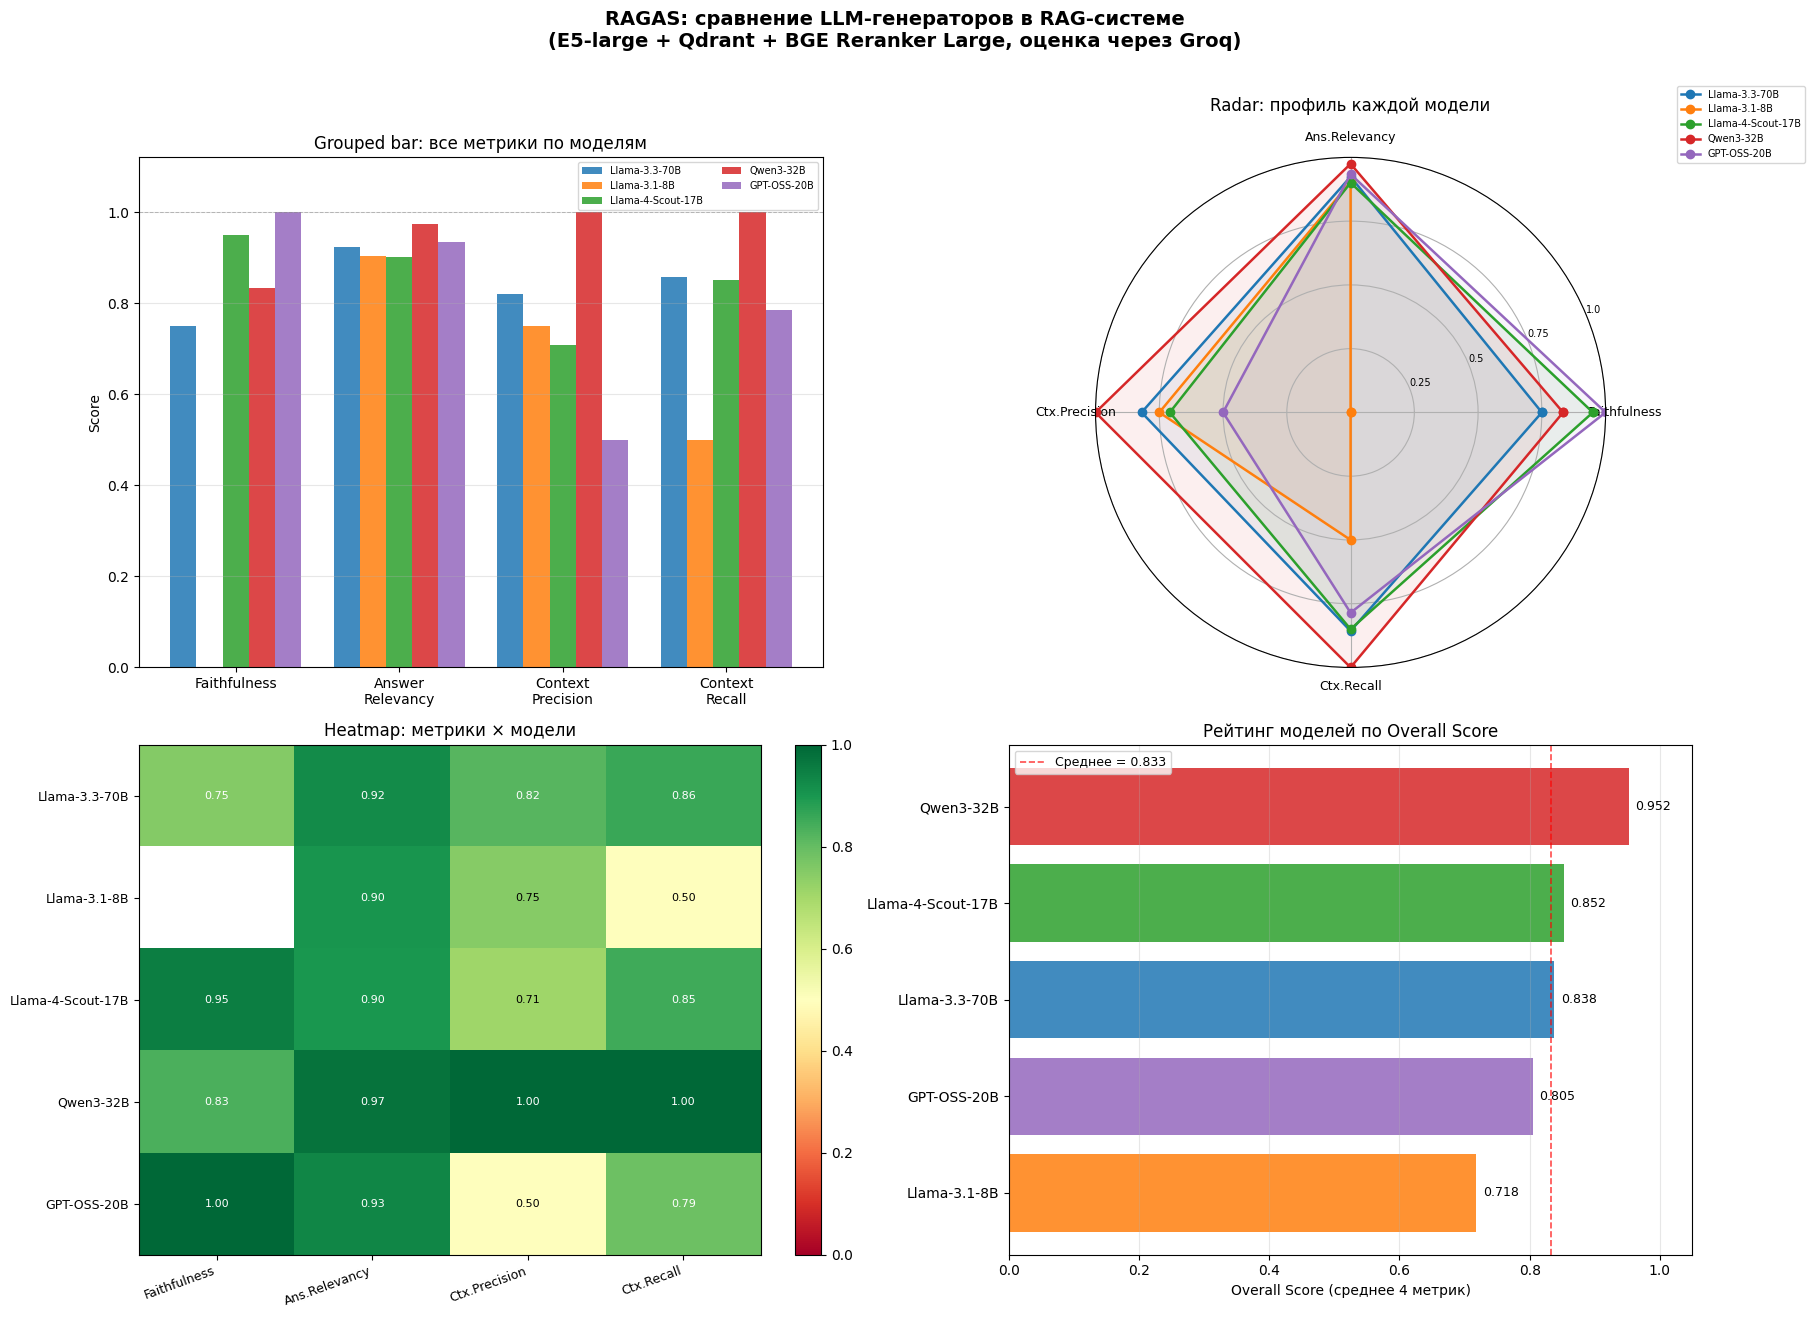

Графики сохранены в ragas_model_comparison.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

SHORT_NAMES = {
    "llama-3.3-70b-versatile":                "Llama-3.3-70B",
    "llama-3.1-8b-instant":                   "Llama-3.1-8B",
    "meta-llama/llama-4-scout-17b-16e-instruct": "Llama-4-Scout-17B",
    "qwen/qwen3-32b":                          "Qwen3-32B",
    "openai/gpt-oss-20b":                      "GPT-OSS-20B",
    # "groq/compound-mini":                      "Groq-Compound-Mini",
}

df_plot = results_df[:-1].copy()
df_plot.index = [SHORT_NAMES.get(m, m) for m in df_plot.index]
metrics_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    "RAGAS: сравнение LLM-генераторов в RAG-системе\n"
    "(E5-large + Qdrant + BGE Reranker Large, оценка через Groq)",
    fontsize=14, fontweight="bold", y=1.01
)

# ── grouped bar по метрикам ──────────────────────────────────────
ax1 = axes[0, 0]
models_list = df_plot.index.tolist()
x = np.arange(len(metrics_cols))
bar_w = 0.8 / len(models_list)
for i, model in enumerate(models_list):
    vals = [df_plot.loc[model, m] for m in metrics_cols]
    offset = (i - len(models_list)/2 + 0.5) * bar_w
    bars = ax1.bar(x + offset, vals, bar_w, label=model, color=palette[i], alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"])
ax1.set_ylim(0, 1.12)
ax1.set_ylabel("Score")
ax1.set_title("Grouped bar: все метрики по моделям")
ax1.legend(fontsize=7, ncol=2)
ax1.axhline(1.0, color="gray", lw=0.7, ls="--", alpha=0.5)
ax1.grid(axis="y", alpha=0.3)

# ── Radar / Spider ───────────────────────────────────────────────
ax2 = axes[0, 1]
ax2.remove()
ax2 = fig.add_subplot(2, 2, 2, polar=True)

N = len(metrics_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

labels_radar = ["Faithfulness", "Ans.Relevancy", "Ctx.Precision", "Ctx.Recall"]
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels_radar, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7)
ax2.set_title("Radar: профиль каждой модели", pad=15)

for i, model in enumerate(models_list):
    vals = [df_plot.loc[model, m] for m in metrics_cols]
    # заменяем NaN на 0
    vals = [0.0 if np.isnan(v) else v for v in vals]
    vals += vals[:1]
    ax2.plot(angles, vals, "o-", lw=1.8, color=palette[i], label=model)
    ax2.fill(angles, vals, alpha=0.07, color=palette[i])

ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=7)

# ── Heatmap ─────────────────────────────────────────────────────
ax3 = axes[1, 0]
heat_data = df_plot[metrics_cols].values.astype(float)
im = ax3.imshow(heat_data, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax3.set_xticks(range(len(metrics_cols)))
ax3.set_xticklabels(["Faithfulness", "Ans.Relevancy", "Ctx.Precision", "Ctx.Recall"],
                    rotation=20, ha="right", fontsize=9)
ax3.set_yticks(range(len(models_list)))
ax3.set_yticklabels(models_list, fontsize=9)
ax3.set_title("Heatmap: метрики × модели")
plt.colorbar(im, ax=ax3, fraction=0.04)
# аннотации значений
for row in range(heat_data.shape[0]):
    for col in range(heat_data.shape[1]):
        v = heat_data[row, col]
        txt = f"{v:.2f}" if not np.isnan(v) else "N/A"
        ax3.text(col, row, txt, ha="center", va="center", fontsize=8,
                 color="black" if 0.3 < v < 0.75 else "white")

# ── Overall score ranking ───────────────────────────────────────
ax4 = axes[1, 1]
overall = df_plot["overall"].sort_values(ascending=True)
colors_bar = [palette[models_list.index(m)] for m in overall.index]
bars = ax4.barh(overall.index, overall.values, color=colors_bar, alpha=0.85)
ax4.set_xlim(0, 1.05)
ax4.set_xlabel("Overall Score (среднее 4 метрик)")
ax4.set_title("Рейтинг моделей по Overall Score")
ax4.axvline(overall.values.mean(), color="red", lw=1.2, ls="--", alpha=0.7,
            label=f"Среднее = {overall.values.mean():.3f}")
ax4.legend(fontsize=9)
ax4.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, overall.values):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ragas_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Графики сохранены в ragas_model_comparison.png")


In [17]:
print("\n Лучшая модель по каждой метрике:")
for col in ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "overall"]:
    best = results_df[col].idxmax()
    best_short = SHORT_NAMES.get(best, best)
    print(f"  {col:22s}: {best_short}  ({results_df.loc[best, col]:.3f})")

print("\n Таблица (отсортирована по overall):")
print(results_df.sort_values("overall", ascending=False).round(3).to_string())



 Лучшая модель по каждой метрике:
  faithfulness          : GPT-OSS-20B  (1.000)
  answer_relevancy      : Qwen3-32B  (0.975)
  context_precision     : Qwen3-32B  (1.000)
  context_recall        : Qwen3-32B  (1.000)
  overall               : Qwen3-32B  (0.952)

 Таблица (отсортирована по overall):
                                           faithfulness  answer_relevancy  context_precision  context_recall  overall
model                                                                                                                
qwen/qwen3-32b                                    0.833             0.975              1.000           1.000    0.952
meta-llama/llama-4-scout-17b-16e-instruct         0.950             0.901              0.709           0.850    0.852
llama-3.3-70b-versatile                           0.750             0.924              0.819           0.857    0.838
openai/gpt-oss-20b                                1.000             0.934              0.500           0.786  